# Next-Word Prediction: Domain-Specific Language Models

This notebook trains **two next-word prediction models** on different text domains to explore how language style affects word prediction:

| Model | Dataset | Domain |
|---|---|---|
| `news_model` | AG News | Modern news writing |
| `gutenberg_model` | NLTK Gutenberg corpus | Classic literature |

## Architecture
Each model uses a **BiLSTM + Self-Attention** stack with pre-trained GloVe word embeddings:
- **GloVe 100d embeddings** — initialise with real-world word semantics
- **Bidirectional LSTM** — captures context from both directions in the input sequence
- **Self-Attention** — lets the model focus on the most relevant context tokens
- **Dropout (0.5)** — regularisation to reduce overfitting

## Speed Optimisations
- Native TF tensor slicing instead of `tf.py_function` callbacks (removes Python GIL bottleneck)
- GloVe 100d instead of 300d (3x smaller embedding matrix, same quality for this task)
- Vocab size 10k (output Dense layer is the main compute bottleneck; halving it ~doubles speed)
- Sequence length 20 (sufficient context for next-word prediction)
- Token cap of 300k per corpus

> **Runtime:** Enable GPU in Colab (`Runtime → Change runtime type → T4 GPU`) for best performance.

## 1. Setup

In [1]:
!pip install tensorflow-datasets nltk --quiet

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow_datasets as tfds
import nltk
from nltk.corpus import gutenberg
import matplotlib.pyplot as plt
import pickle
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU available: True


## 2. Load Datasets

In [2]:
# --- AG News (News model) ---
dataset, info = tfds.load('ag_news_subset', with_info=True, as_supervised=False)
train_data = dataset['train']
news_texts = [example['description'].decode('utf-8') for example in tfds.as_numpy(train_data)]
news_text = " ".join(news_texts)
print(f"AG News characters: {len(news_text):,}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.R4WSL4_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.R4WSL4_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.
AG News characters: 23,328,241


In [3]:
# --- Gutenberg Corpus (Literature model) ---
nltk.download('gutenberg')
book_ids = gutenberg.fileids()
print(f"Loading {len(book_ids)} Gutenberg books...")
gutenberg_text = " ".join(gutenberg.raw(b) for b in book_ids)
print(f"Gutenberg characters: {len(gutenberg_text):,}")

Loading 18 Gutenberg books...
Gutenberg characters: 11,793,335


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


## 3. Model Architecture & Training Pipeline

In [6]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
EMBEDDING_DIM  = 100    # GloVe 100d — faster than 300d, sufficient for this task
VOCAB_SIZE     = 10000  # Smaller vocab = much faster Dense output layer
MAX_SEQ_LEN    = 20     # Context window length
MAX_TOKENS     = 300000 # Token cap per corpus (keeps training time reasonable)
BATCH_SIZE     = 256    # Larger batches → better GPU utilisation
STEPS_PER_EPOCH = 1500
EPOCHS         = 15


def load_glove_embeddings(vocab_size, tokenizer, dim=100):
    """Download GloVe and build an embedding matrix for the tokenizer vocab."""
    glove_zip = tf.keras.utils.get_file(
        'glove.6B.zip',
        'https://nlp.stanford.edu/data/glove.6B.zip',
        extract=True
    )
    # get_file returns the path to the zip; embeddings are in the same dir
    target = f'glove.6B.{dim}d.txt'
    glove_dir = os.path.dirname(glove_zip)
    candidates = [
        os.path.join(glove_dir, target),
        os.path.join(glove_dir, 'glove.6B', target),
    ]
    glove_file = next((p for p in candidates if os.path.exists(p)), None)
    if glove_file is None:
        for root, dirs, files in os.walk(os.path.dirname(glove_dir)):
            if target in files:
                glove_file = os.path.join(root, target)
                break
    if glove_file is None:
        raise FileNotFoundError(f"Could not find {target}. Delete ~/.keras/datasets/glove.6B.zip and re-run.")

    embeddings_index = {}
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

    embedding_matrix = np.zeros((vocab_size, dim))
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

    coverage = sum(
        1 for w, i in tokenizer.word_index.items()
        if i < vocab_size and w in embeddings_index
    ) / vocab_size
    print(f"GloVe coverage: {coverage:.1%} of vocab")
    return embedding_matrix


def build_model(vocab_size, embedding_matrix, max_seq_len):
    """BiLSTM + Self-Attention model for next-word prediction."""
    inputs  = layers.Input(shape=(max_seq_len,))
    embed   = layers.Embedding(
                  vocab_size, EMBEDDING_DIM,
                  weights=[embedding_matrix],
                  trainable=True)(inputs)
    bilstm  = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(embed)
    attn    = layers.Attention()([bilstm, bilstm])
    context = layers.GlobalAveragePooling1D()(attn)
    dropped = layers.Dropout(0.5)(context)
    outputs = layers.Dense(vocab_size, activation='softmax')(dropped)

    model = Model(inputs, outputs)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


def make_dataset(seq_np, max_seq_len, batch_size):
    """
    Build a fast tf.data pipeline using native tensor slicing.

    Key optimisation: wrap the token array in a tf.constant so all slicing
    happens inside the TF graph — no tf.py_function overhead, no Python GIL.
    """
    seq_tf      = tf.constant(seq_np, dtype=tf.int32)
    num_samples = len(seq_np) - max_seq_len

    def get_sample(i):
        x = seq_tf[i : i + max_seq_len]
        y = seq_tf[i + max_seq_len]
        return x, y

    dataset = (
        tf.data.Dataset.range(num_samples)
        .shuffle(buffer_size=50000, reshuffle_each_iteration=True)
        .map(get_sample, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataset


def train_model(text, model_name,
                vocab_size=VOCAB_SIZE, max_seq_len=MAX_SEQ_LEN,
                batch_size=BATCH_SIZE, steps_per_epoch=STEPS_PER_EPOCH,
                max_tokens=MAX_TOKENS):
    """Tokenise, build, and train a next-word prediction model."""
    print(f"\n{'='*50}")
    print(f"  Training: {model_name}")
    print(f"{'='*50}")

    # 1. Tokenise
    tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
    tokenizer.fit_on_texts([text])
    full_seq = tokenizer.texts_to_sequences([text])[0]
    if len(full_seq) > max_tokens:
        full_seq = full_seq[:max_tokens]
    seq_np = np.array(full_seq, dtype=np.int32)
    print(f"Tokens used: {len(seq_np):,}")

    # 2. GloVe embeddings + model
    embedding_matrix = load_glove_embeddings(vocab_size, tokenizer, dim=EMBEDDING_DIM)
    model = build_model(vocab_size, embedding_matrix, max_seq_len)
    model.summary()

    # 3. tf.data pipeline
    dataset = make_dataset(seq_np, max_seq_len, batch_size)

    # 4. Train
    callbacks = [
        EarlyStopping(monitor='loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='loss', save_best_only=True)
    ]
    history = model.fit(
        dataset.repeat(),
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # 5. Save
    model.save(f'{model_name}.keras')
    with open(f'{model_name}_tokenizer.pickle', 'wb') as f:
        pickle.dump(tokenizer, f)
    print(f"\n{model_name} saved.")

    return model, tokenizer, history

## 4. Train Both Models

In [7]:
news_model, news_tokenizer, news_history = train_model(news_text, "news_model")

gutenberg_model, gutenberg_tokenizer, gutenberg_history = train_model(gutenberg_text, "gutenberg_model")


  Training: news_model
Tokens used: 300,000
GloVe coverage: 98.1% of vocab


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 100)   │  1,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 20, 128)   │     84,480 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 20, 128)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10000)     │  1,290,000 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,374,480 (9.06 MB)

 Trainable params: 2,374,480 (9.06 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 20, 100)   │  1,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 20, 128)   │     84,480 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 20, 128)   │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10000)     │  1,290,000 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,374,480 (9.06 MB)

 Trainable params: 2,374,480 (9.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.0523 - loss: 6.0836
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.1031 - loss: 5.5154
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.1208 - loss: 5.3118
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.1296 - loss: 5.1822
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.1361 - loss: 5.0834
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.1413 - loss: 5.0284
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.1439 - loss: 4.9716
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.1481 - loss: 4.9060
Epoch 9/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.1516 - loss: 4.8595
Epoch 10/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.1537 - loss: 4.8228
Epoch 11/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.1555 - loss: 4.7823
Epoch 12

## 5. Training Results

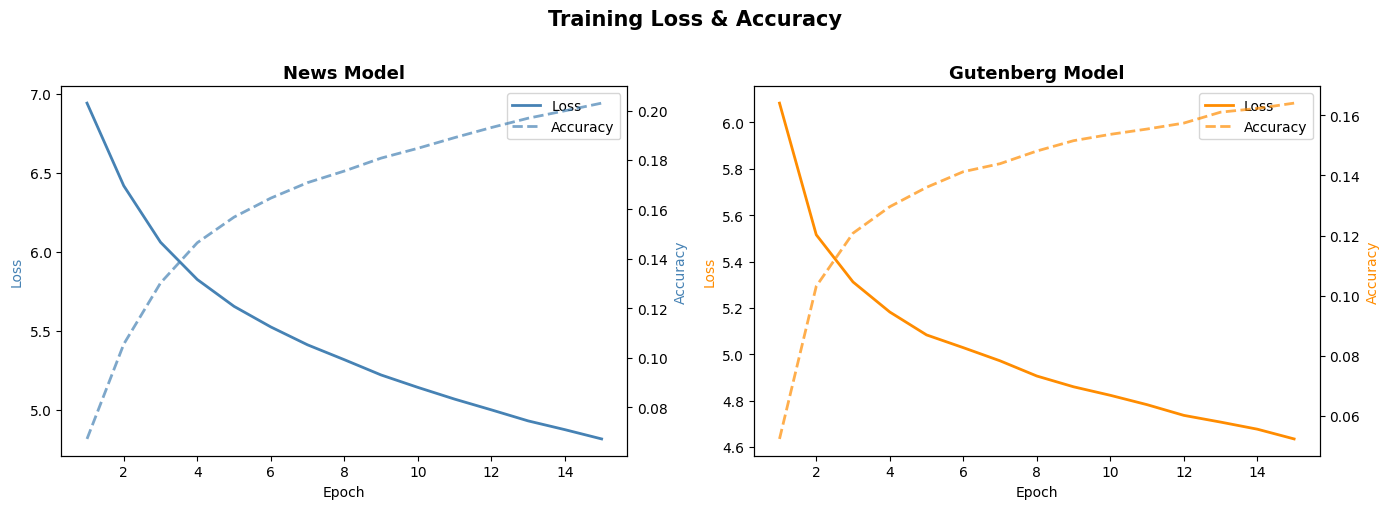

News         → Final loss: 4.8140 | Final accuracy: 0.2030
Gutenberg    → Final loss: 4.6345 | Final accuracy: 0.1641


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, name, color in zip(
    axes,
    [news_history, gutenberg_history],
    ['News Model', 'Gutenberg Model'],
    ['steelblue', 'darkorange']
):
    epochs = range(1, len(history.history['loss']) + 1)

    ax2 = ax.twinx()
    ax.plot(epochs, history.history['loss'],     color=color,  lw=2,   label='Loss')
    ax2.plot(epochs, history.history['accuracy'], color=color,  lw=2,
             linestyle='--', alpha=0.7, label='Accuracy')

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color=color)
    ax2.set_ylabel('Accuracy', color=color)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.suptitle('Training Loss & Accuracy', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final metrics
for history, name in [(news_history, 'News'), (gutenberg_history, 'Gutenberg')]:
    final_loss = history.history['loss'][-1]
    final_acc  = history.history['accuracy'][-1]
    print(f"{name:12s} → Final loss: {final_loss:.4f} | Final accuracy: {final_acc:.4f}")

## 6. Prediction Demo

Compare how the two domain-specific models predict differently from the same seed text.

In [9]:
def predict_next_words(seed_text, model, tokenizer, n_words=5, top_k=3):
    """
    Predict the next n_words from a seed string.
    Returns the completed text and a breakdown of top-k predictions at each step.
    """
    text = seed_text.lower()
    steps = []

    for _ in range(n_words):
        seq      = tokenizer.texts_to_sequences([text])[0][-MAX_SEQ_LEN:]
        padded   = tf.keras.preprocessing.sequence.pad_sequences(
                       [seq], maxlen=MAX_SEQ_LEN, padding='pre')
        probs    = model.predict(padded, verbose=0)[0]
        top_ids  = probs.argsort()[-top_k:][::-1]

        # Reverse-lookup words
        idx2word = {v: k for k, v in tokenizer.word_index.items()}
        top_words = [(idx2word.get(i, '<OOV>'), float(probs[i])) for i in top_ids]
        steps.append(top_words)

        best_word = top_words[0][0]
        text     += ' ' + best_word

    return text, steps


def compare_models(seed):
    print(f"\nSeed: \"{seed}\"")
    print("-" * 60)
    for model, tokenizer, label in [
        (news_model,      news_tokenizer,      "News     "),
        (gutenberg_model, gutenberg_tokenizer, "Gutenberg")
    ]:
        result, steps = predict_next_words(seed, model, tokenizer, n_words=5)
        print(f"  [{label}] {result}")
        for i, top in enumerate(steps):
            candidates = ", ".join(f"{w} ({p:.2%})" for w, p in top)
            print(f"             step {i+1}: {candidates}")


# ── Run demos ────────────────────────────────────────────────────────────────
compare_models("the government announced")
compare_models("she looked at him and")
compare_models("the market saw a significant")


Seed: "the government announced"
------------------------------------------------------------
  [News     ] the government announced friday the <OOV> <OOV> <OOV>
             step 1: friday (12.94%), thursday (9.39%), monday (7.83%)
             step 2: the (3.53%), <OOV> (2.74%), he (2.57%)
             step 3: <OOV> (2.14%), european (0.75%), world (0.63%)
             step 4: <OOV> (3.47%), of (1.04%), victory (0.35%)
             step 5: <OOV> (4.38%), of (1.30%), the (0.85%)
  [Gutenberg] the government announced the same passages were equally
             step 1: the (1.58%), place (1.13%), their (0.85%)
             step 2: same (0.65%), youngest (0.63%), youthful (0.59%)
             step 3: passages (0.57%), county (0.53%), spots (0.50%)
             step 4: were (4.34%), was (3.86%), had (2.32%)
             step 5: equally (0.44%), seated (0.42%), displayed (0.37%)

Seed: "she looked at him and"
------------------------------------------------------------
  [News     ] she 

## 7. Save Files

Run the cell below **only in Google Colab** to download the trained models.

In [ ]:
# List saved files
print("Saved files:")
for f in sorted(os.listdir('.')):
    if f.endswith(('.keras', '.pickle', '.png')):
        size_mb = os.path.getsize(f) / 1e6
        print(f"  {f:<45} {size_mb:.1f} MB")

# Uncomment to download in Google Colab:
# from google.colab import files
# for fname in ['news_model.keras', 'news_model_tokenizer.pickle',
#               'gutenberg_model.keras', 'gutenberg_model_tokenizer.pickle',
#               'training_curves.png']:
#     files.download(fname)